In [10]:
# import json
# from collections import Counter

# # 1. Открываем файл с датасетом
# with open("images_5_classes_1000_original.json", "r", encoding="utf-8") as f:
#     data = json.load(f)  # Загружаем JSON в Python как список словарей

# # 2. Собираем все значения класса
# classes = [item["class"] for item in data]

# # 3. Считаем количество промптов для каждого класса
# class_counts = Counter(classes)

# # 4. Выводим результат
# for cls, count in class_counts.items():
#     print(f"{cls}: {count}")


# Генератор картинок

In [4]:
from diffusers import StableDiffusionPipeline
print("OK")

OK


In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


In [7]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [9]:
from dotenv import load_dotenv
import os

load_dotenv()
print(os.getenv("HF_HOME"))

D:/Netology/hf_cache


In [9]:
import os
print(os.environ.get("HF_HOME"))

D:/Netology/hf_cache


In [1]:
from dotenv import load_dotenv
import torch
from diffusers import StableDiffusionPipeline

# 1. Загружаем env
load_dotenv()

# 2. Проверка GPU
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

# 3. Загружаем pipeline (SD 1.5)
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    cache_dir="D:/Netology/hf_cache",
    torch_dtype=torch.float16,
)

# 4. Переносим на GPU
pipe = pipe.to("cuda")

print("Pipeline loaded successfully")

d:\anaconda3\envs\netology\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Device: NVIDIA GeForce RTX 3060


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 261.31it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: D:\Netology\hf_cache\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 396/396 [00:01<00:00, 254.36it/s, Materializing param=visual_projection.weight]
StableDiffusionSafetyChecker LOAD REPORT from: D:\Netology\hf_cache\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_mod

Pipeline loaded successfully


In [18]:
negative_prompt = (
    "low quality, worst quality, blurry, "
    "extra limbs, extra fingers, "
    "deformed, mutated, "
    "bad anatomy, bad proportions, "
    "text, watermark, logo, "
    "cropped, out of frame"
)

In [ ]:
prompt = "Newfoundland dog, water rescue, heroic, powerful, action, detailed, dramatic"

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

image.save("dog_clean.png")

100%|██████████| 30/30 [00:05<00:00,  5.43it/s]


In [26]:
prompt = "Newfoundland dog, water rescue, heroic, powerful, action, detailed, dramatic"

gen = torch.Generator("cuda").manual_seed(42)

image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    generator=gen,
    num_inference_steps=30,
    guidance_scale=7.5,
).images[0]

image.save("dog_clean_2.png")

100%|██████████| 30/30 [00:05<00:00,  5.48it/s]


Правильный паттерн для датасета

Вариант 1 — фиксируем seed на каждый вызов

    def generate_image(prompt, seed):

        gen = torch.Generator("cuda").manual_seed(seed)
        
        return pipe(prompt, generator=gen).images[0]

    img = generate_image("a photo of a cat", seed=123)

Вариант 2 — seed = id картинки (лучший для датасетов)

    for i in range(100):
        gen = torch.Generator("cuda").manual_seed(i)

        image = pipe(prompt, generator=gen).images[0]
        
        image.save(f"cat_{i}.png")

Потоковая генерация

In [29]:
prompts = {
    "airplane": "a photo of an airplane, realistic, high quality",
    "car": "a photo of a car, realistic, high quality",
    "cat": "a photo of a cat, realistic, high quality",
    "dog": "a photo of a dog, realistic, high quality",
    "flower": "a photo of a flower, macro photography",
    "fruit": "a photo of fruit on a table, realistic",
    "motorbike": "a photo of a motorbike, realistic",
    "person": "a photo of a person, portrait photography"
}


In [30]:
import os
import torch
from tqdm import tqdm

BASE_DIR = "dataset_generated"
IMAGES_PER_CLASS = 30

os.makedirs(BASE_DIR, exist_ok=True)

for class_name, prompt in prompts.items():
    class_dir = os.path.join(BASE_DIR, class_name)
    os.makedirs(class_dir, exist_ok=True)

    for i in tqdm(range(IMAGES_PER_CLASS), desc=f"Generating {class_name}"):
        #gen = torch.Generator("cuda").manual_seed(i) - убрала, потому что мне на каждый промт нужно 20 разных картинок

        image = pipe(
            prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=30,
            guidance_scale=7.5,
        ).images[0]

        image.save(os.path.join(class_dir, f"{class_name}_{i}.png"))


100%|██████████| 30/30 [00:04<00:00,  7.13it/s]<01:40,  4.39s/it]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
100%|██████████| 30/30 [00:04<00:00,  7.26it/s]4<00:48,  4.42s/it]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
100%|██████████| 30/30 [00:04<00:00,  7.21it/s]0<00:53,  4.43s/it]
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.
Generating person: 100%|██████████| 30/30 [02:13<00:00,  4.46s/it]


В следующий раз добавь:

      import time

      time.sleep(0.2) # пауза между генерациями, дольше, но меньше нагрузки на карту

А то температура у видюхи росла

# LLM + LoRa для промтов

Берем:

Falcon-7B-Instruct (открытая, поддерживает русские запросы и LoRA)

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from dotenv import load_dotenv
import os

In [19]:
# 1. Загружаем env
load_dotenv()
cache_dir = os.getenv("HF_HOME")  # D:/Netology/hf_cache

# 2. Проверяем GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device=="cuda" else "CPU")

# 3. Загружаем токенайзер и модель
model_name = "tiiuae/falcon-7b-instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    cache_dir=cache_dir,
    torch_dtype=torch.float16,  # экономим VRAM
    device_map="auto"            # автоматически распределяет модель по GPU
)

print("Model loaded successfully!")

Device: cuda NVIDIA GeForce RTX 3060


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 196/196 [00:08<00:00, 24.40it/s, Materializing param=transformer.word_embeddings.weight]                    
The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
Some parameters are on the meta device because they were offloaded to the cpu.


Model loaded successfully!


In [15]:
import json
from collections import Counter

# 1. Открываем файл с датасетом
with open("eval_for_model.json", "r", encoding="utf-8") as f:
    data = json.load(f)  # Загружаем JSON в Python как список словарей

# 2. Собираем все значения класса
classes = [item["class"] for item in data]

# 3. Считаем количество промптов для каждого класса
class_counts = Counter(classes)

# 4. Выводим результат
for cls, count in class_counts.items():
    print(f"{cls}: {count}")


cat: 12
dog: 12
car: 12
airplane: 12
flower: 12
fruit: 12
motorbike: 12
person: 12


In [16]:
with open("images_5_classes_clean.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

In [16]:
import json

# data — твой список словарей
with open("eval_for_model.jsonl", "w", encoding="utf-8") as f:
    for item in data:
        # убираем поле class
        example = {
            "instruction": item["instruction"],
            "input": item["input"],
            "output": item["output"]
        }
        f.write(json.dumps(example, ensure_ascii=False) + "\n")

Токинезатор

In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer

from peft import LoraConfig, TaskType

from peft import get_peft_model # подключение модели к модели

from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq
from peft import get_peft_model, LoraConfig, TaskType

Можно было бы так еще, но написано, что небезопасно, если не уверена в длине последовательности

- В этом варианте код автоматически настраивает длинну, не круто, если у тебя найдется очень длинная последовательность, не влезет в память

In [ ]:
# def tokenize_fn(example):
#     prompt = f"{example['instruction']}\n{example['input']}"
#     output = example['output']

#     tokenized = tokenizer(prompt, truncation=True)
#     labels = tokenizer(output, truncation=True)
#     tokenized["labels"] = labels["input_ids"]
#     return tokenized

# data_collator = DataCollatorForSeq2Seq(tokenizer, padding=True, return_tensors="pt")

Берем вариант с нашим ограничением длинны, которое мы тоже подбили под длинну последовательности

In [5]:
# 2. Загружаем JSONL датасет
dataset = load_dataset("json", data_files="images_5_classes.jsonl", split="train")
tokenizer.pad_token = tokenizer.eos_token

# 3. Создаем функцию токенизации
def tokenize_fn(example):
    prompt = f"{example['instruction']}\n{example['input']}"
    output = example['output']

    tokenized = tokenizer(
        prompt,
        truncation=True, 
        max_length=128, # изначально ставила 256, потом ниже смотрела реальный максимум последовательности и уменьшила под реальные данные
        padding="max_length")

    labels = tokenizer(
        output, 
        truncation=True,
        max_length=128, # также ставила сначала 128, потом уменьшила, было 32, но должен быть равен блядь входу
        padding="max_length")
    
    # Заменяем padding токены на -100, чтобы лосс игнорировал их
    labels["input_ids"] = [
        (l if l != tokenizer.pad_token_id else -100) for l in labels["input_ids"]
    ]

    tokenized["labels"] = labels["input_ids"]
    return tokenized


# 4. Применяем токенизацию ко всему датасету
tokenized_dataset = dataset.map(tokenize_fn, batched=False)

print(tokenized_dataset[0])

Map: 100%|██████████| 505/505 [00:00<00:00, 1112.56 examples/s]

{'instruction': 'Создай промпт для генерации изображения на английском', 'input': 'милый котенок с зелеными глазами', 'output': '1cat, kitten, cute, green eyes, detailed fur, masterpiece, best quality', 'input_ids': [60800, 150, 134, 38452, 24111, 11944, 129, 25311, 23483, 134, 150, 132, 31419, 8431, 40390, 15401, 19898, 5052, 123, 12326, 133, 45825, 6279, 43548, 7795, 7795, 32797, 38452, 150, 134, 36258, 40805, 126, 12326, 133, 50079, 5052, 133, 6279, 29819, 150, 133, 150, 123, 15401, 18945, 129, 47043, 150, 134, 150, 132, 193, 150, 132, 7795, 15401, 49878, 129, 60038, 134, 8431, 12326, 133, 150, 134, 16153, 24299, 55175, 47005, 12326, 133, 49878, 132, 7795, 5052, 123, 15401, 60036, 11944, 132, 7795, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

Технология такая, ставишь длину побольше 256 на вход и 128 на выход, например, строишь и смотришь реальную максимальную длинну токенов из датасета, и дальше под нее уже подставляешь (если около 100 - 128, если меньше 60 - 64, если больше 128 - 256 вроде и так далее)

In [26]:
# посчитаем максимальную длину instruction + input
max_len = max(len(tokenizer(f"{ex['instruction']}\n{ex['input']}")['input_ids']) for ex in data)
print(max_len)

105


In [27]:
# посчитаем максимальную длину output
max_out_len = max(len(tokenizer(ex['output'])['input_ids']) for ex in data)
print(max_out_len)

23


Настраиваем параметры LoRa

In [6]:
from peft import LoraConfig, TaskType

lora_config = LoraConfig(
    r=8,                     # размер low-rank
    lora_alpha=16,           # коэффициент масштабирования
    target_modules = ["query_key_value"],  # какие части модели дообучаем
    lora_dropout=0.05,       # dropout для LoRA
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

Подключаем наш lora_config к модели

In [8]:
from peft import get_peft_model

# Подключаем LoRA к нашей модели
model = get_peft_model(model, lora_config)

# Проверим, сколько параметров обучаемых
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

base_model.model.transformer.h.0.self_attention.query_key_value.lora_A.default.weight torch.Size([8, 4544])
base_model.model.transformer.h.0.self_attention.query_key_value.lora_B.default.weight torch.Size([4672, 8])
base_model.model.transformer.h.1.self_attention.query_key_value.lora_A.default.weight torch.Size([8, 4544])
base_model.model.transformer.h.1.self_attention.query_key_value.lora_B.default.weight torch.Size([4672, 8])
base_model.model.transformer.h.2.self_attention.query_key_value.lora_A.default.weight torch.Size([8, 4544])
base_model.model.transformer.h.2.self_attention.query_key_value.lora_B.default.weight torch.Size([4672, 8])
base_model.model.transformer.h.3.self_attention.query_key_value.lora_A.default.weight torch.Size([8, 4544])
base_model.model.transformer.h.3.self_attention.query_key_value.lora_B.default.weight torch.Size([4672, 8])
base_model.model.transformer.h.4.self_attention.query_key_value.lora_A.default.weight torch.Size([8, 4544])
base_model.model.transformer

Кол-во обучаемых параметров

In [9]:
trainable_params = 0
total_params = 0

for name, param in model.named_parameters():
    num = param.numel()  # количество элементов в тензоре
    total_params += num
    if param.requires_grad:
        trainable_params += num

print(f"Всего параметров: {total_params}")
print(f"Обучаемых (LoRA): {trainable_params}")
print(f"Процент обучаемых: {trainable_params / total_params * 100:.4f}%")

Всего параметров: 7219549056
Обучаемых (LoRA): 2359296
Процент обучаемых: 0.0327%


Ищем правильное название слоев в модели для target_modules

In [32]:
for name, param in model.named_modules():
    print(name)


transformer
transformer.word_embeddings
transformer.h
transformer.h.0
transformer.h.0.self_attention
transformer.h.0.self_attention.query_key_value
transformer.h.0.self_attention.dense
transformer.h.0.self_attention.attention_dropout
transformer.h.0.mlp
transformer.h.0.mlp.dense_h_to_4h
transformer.h.0.mlp.act
transformer.h.0.mlp.dense_4h_to_h
transformer.h.0.input_layernorm
transformer.h.1
transformer.h.1.self_attention
transformer.h.1.self_attention.query_key_value
transformer.h.1.self_attention.dense
transformer.h.1.self_attention.attention_dropout
transformer.h.1.mlp
transformer.h.1.mlp.dense_h_to_4h
transformer.h.1.mlp.act
transformer.h.1.mlp.dense_4h_to_h
transformer.h.1.input_layernorm
transformer.h.2
transformer.h.2.self_attention
transformer.h.2.self_attention.query_key_value
transformer.h.2.self_attention.dense
transformer.h.2.self_attention.attention_dropout
transformer.h.2.mlp
transformer.h.2.mlp.dense_h_to_4h
transformer.h.2.mlp.act
transformer.h.2.mlp.dense_4h_to_h
trans

In [9]:
for name, module in model.named_modules():
    if "proj" in name or "attention" in name:
        print(name)


model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.post_attention_layernorm
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.post_attention_layernorm
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.k_proj
model.layers.2.self_attn.v_proj
model.layers.2.self_attn.o_proj
model.layers.2.mlp.gate_proj
model.layers.2.mlp.up_proj
model.layers.2.mlp.down_proj
model.layers.2.post_attention_layernorm
model.layers.3.self_attn.q_proj
model.layers.3.self_attn.k_proj
model.layers.3.self_attn.v_proj
model.layers.3.self_attn.o_proj
model.layers.3.mlp.gate_proj
model.layers.3.mlp.up_proj
model.layers.3.mlp.down_proj
model.layers.3.post_attentio

Шаг 2. Подготовим collator

* pad_to_multiple_of=8 помогает ускорить обучение на GPU (выравнивание памяти).

* return_tensors="pt" — чтобы получить PyTorch тензоры.

In [10]:
data_collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8, return_tensors="pt")

In [11]:
training_args = TrainingArguments(
    output_dir="lora_output",    # куда сохраняем веса
    per_device_train_batch_size=2,  # маленький batch для GPU 12GB
    num_train_epochs=3,           # количество эпох
    learning_rate=3e-4,           # шаг обучения для LoRA
    logging_steps=10,             # как часто логируем
    save_steps=100,               # как часто сохраняем чекпоинт
    save_total_limit=2,           # сколько всего чекпоинтов держим
    fp16=True,                     # экономим VRAM
    gradient_accumulation_steps=4, # эффективный batch
)

In [12]:
trainer = Trainer(
    model=model,
    train_dataset=tokenized_dataset,
    #tokenizer=tokenizer, - в старых версиях было надо, сейчас нет, мы токенизировали заранее
    args=training_args,
    data_collator=data_collator,
)

The model is already on multiple devices. Skipping the move to device specified in `args`.


In [13]:
trainer.train()

model.save_pretrained("./lora_output")

RuntimeError: Function MmBackward0 returned an invalid gradient at index 1 - expected device meta but got cuda:0

# Сначала 

In [11]:
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from dotenv import load_dotenv
import os

from datasets import load_dataset
from transformers import AutoTokenizer

from peft import LoraConfig, TaskType

from peft import get_peft_model # подключение модели к модели

from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq
from peft import get_peft_model, LoraConfig, TaskType

In [2]:
# 1. Загружаем env
load_dotenv()
cache_dir = os.getenv("HF_HOME")  # D:/Netology/hf_cache

# 2. Проверяем GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device=="cuda" else "CPU")

Device: cuda NVIDIA GeForce RTX 3060


In [3]:
# 3. Загружаем токенайзер и модель
model_name = "tiiuae/Falcon3-3B-Instruct"  # поменяли только цифру

tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    cache_dir=cache_dir,
    torch_dtype=torch.float16,
    device_map="auto")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:01<00:00, 130.52it/s, Materializing param=model.norm.weight]                              


In [ ]:
# # 2. Загружаем JSONL датасет
# train_dataset = load_dataset("json", data_files="images_5_classes_1000.jsonl", split="train")
# eval_dataset = load_dataset("json", data_files="eval_for_model.jsonl", split="train")
# tokenizer.pad_token = tokenizer.eos_token

# # 3. Создаем функцию токенизации
# def tokenize_fn(example):
#     # 1. Собираем ПОЛНЫЙ текст: промпт + ответ
#     full_text = f"{example['instruction']}\n{example['input']}\n{example['output']}{tokenizer.eos_token}"
    
#     # 2. Токенизируем ВСЮ последовательность
#     tokenized = tokenizer(
#         full_text,
#         truncation=True,
#         max_length=160,  # Можно оставить 128, если примеры короткие
#         padding="max_length"
#     )
    
#     # 3. Копируем input_ids в labels
#     labels = tokenized["input_ids"].copy()
    
#     # 4. Маскируем часть с промптом
#     # Нужно найти, где заканчивается промпт
#     prompt_text = f"{example['instruction']}\n{example['input']}\n"
#     prompt_tokens = tokenizer.encode(prompt_text, add_special_tokens=False)
    
#     # 5. Заменяем токены промпта на -100
#     for i in range(len(prompt_tokens)):
#         labels[i] = -100
    
#     # 6. Возвращаем
#     tokenized["labels"] = labels
#     return tokenized


# # 4. Применяем токенизацию ко всему датасету
# tokenized_train = train_dataset.map(
#     tokenize_fn,
#     remove_columns=train_dataset.column_names,
# )

# tokenized_eval = eval_dataset.map(
#     tokenize_fn,
#     remove_columns=eval_dataset.column_names,
# )

Map: 100%|██████████| 96/96 [00:00<00:00, 1714.30 examples/s]


In [4]:
# 2. Загружаем JSONL датасет
train_dataset = load_dataset("json", data_files="images_5_classes_1000.jsonl", split="train")
eval_dataset = load_dataset("json", data_files="eval_for_model.jsonl", split="train")

In [5]:
def tokenize_fn(example):
    # 1. Собираем полный текст (без eos_token в конце)
    full_text = f"{example['instruction']}\n{example['input']}\n{example['output']}"
    
    # 2. Токенизируем БЕЗ PADDING
    tokenized = tokenizer(
        full_text,
        truncation=True,
        max_length=160,  # 105 (промпт) + 32 (ответ) + запас = 160
        padding=False  # КЛЮЧЕВОЕ ИЗМЕНЕНИЕ!
    )
    
    # 3. Находим длину промпта в токенах
    prompt_text = f"{example['instruction']}\n{example['input']}\n"
    prompt_len = len(tokenizer.encode(prompt_text, add_special_tokens=False))
    
    # 4. Создаем labels: -100 для промпта, реальные токены для ответа
    labels = [-100] * prompt_len + tokenized["input_ids"][prompt_len:]
    
    # 5. Возвращаем
    tokenized["labels"] = labels
    return tokenized

In [6]:
# 4. Применяем токенизацию ко всему датасету
tokenized_train = train_dataset.map(
    tokenize_fn,
    remove_columns=train_dataset.column_names,
)

tokenized_eval = eval_dataset.map(
    tokenize_fn,
    remove_columns=eval_dataset.column_names,
)

In [14]:
# Найти реальный максимум
lengths = [len(x['input_ids']) for x in tokenized_train]
print(f"Min: {min(lengths)}, Max: {max(lengths)}, Avg: {sum(lengths)/len(lengths):.1f}")

Min: 72, Max: 142, Avg: 96.2


In [29]:
tokenized_train

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1033
})

In [30]:
print(tokenized_train[0])

{'input_ids': [62218, 2162, 2146, 45473, 30036, 16746, 2141, 86935, 2146, 2162, 2144, 31369, 12660, 112895, 8630, 2135, 17000, 2145, 51875, 109954, 86245, 40605, 91135, 2146, 39477, 46107, 2138, 17000, 2145, 52700, 8630, 2145, 10124, 45204, 2162, 2145, 2162, 2135, 20937, 25056, 2141, 99334, 2146, 2162, 2144, 12, 2162, 2144, 11821, 20937, 60887, 2141, 75651, 2146, 12660, 17000, 2145, 2162, 2146, 21439, 31444, 66892, 54779, 17000, 2145, 60887, 2144, 11821, 8630, 2135, 20937, 84475, 16746, 2144, 11821, 12, 2040, 10240, 2035, 45842, 2035, 11761, 2035, 6023, 5508, 2035, 8766, 13550, 2035, 31892, 2035, 3088, 4103], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -

In [7]:
# Посмотреть на один пример
test_example = tokenized_train[0]

# Декодируем input_ids
full_text = tokenizer.decode(test_example['input_ids'])
print("Full text:", full_text[:200], "...")

# Посчитаем, сколько реальных токенов в labels
real_tokens = sum(1 for t in test_example['labels'] if t != -100)
print(f"Real tokens in labels: {real_tokens}")

# Декодируем только часть для обучения
output_part = [t for t in test_example['labels'] if t != -100]
print("What model learns to predict:", tokenizer.decode(output_part))

Full text: Создай промпт для генерации изображения на английском
милый котенок с зелеными глазами
1cat, kitten, cute, green eyes, detailed fur, masterpiece, best quality ...
Real tokens in labels: 17
What model learns to predict: 1cat, kitten, cute, green eyes, detailed fur, masterpiece, best quality


In [8]:
# Настраиваем LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "down_proj"], # программа максимум для этой задачи ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

# минимально "q_proj", "k_proj", "v_proj"

In [33]:
for name, param in model.named_modules():
    print(name)


model
model.embed_tokens
model.layers
model.layers.0
model.layers.0.self_attn
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.mlp
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.mlp.act_fn
model.layers.0.input_layernorm
model.layers.0.post_attention_layernorm
model.layers.1
model.layers.1.self_attn
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.mlp
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.mlp.act_fn
model.layers.1.input_layernorm
model.layers.1.post_attention_layernorm
model.layers.2
model.layers.2.self_attn
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.k_proj
model.layers.2.self_attn.v_proj
model.layers.2.self_attn.o_proj
model.layers.2.mlp
model.layers.2.mlp.gate_proj
model.l

In [34]:
for name, module in model.named_modules():
    if "proj" in name or "attention" in name:
        print(name)

model.layers.0.self_attn.q_proj
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.v_proj
model.layers.0.self_attn.o_proj
model.layers.0.mlp.gate_proj
model.layers.0.mlp.up_proj
model.layers.0.mlp.down_proj
model.layers.0.post_attention_layernorm
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.v_proj
model.layers.1.self_attn.o_proj
model.layers.1.mlp.gate_proj
model.layers.1.mlp.up_proj
model.layers.1.mlp.down_proj
model.layers.1.post_attention_layernorm
model.layers.2.self_attn.q_proj
model.layers.2.self_attn.k_proj
model.layers.2.self_attn.v_proj
model.layers.2.self_attn.o_proj
model.layers.2.mlp.gate_proj
model.layers.2.mlp.up_proj
model.layers.2.mlp.down_proj
model.layers.2.post_attention_layernorm
model.layers.3.self_attn.q_proj
model.layers.3.self_attn.k_proj
model.layers.3.self_attn.v_proj
model.layers.3.self_attn.o_proj
model.layers.3.mlp.gate_proj
model.layers.3.mlp.up_proj
model.layers.3.mlp.down_proj
model.layers.3.post_attentio

In [9]:
model = get_peft_model(model, lora_config)

trainable_params = 0
total_params = 0

for name, param in model.named_parameters():
    num = param.numel()  # количество элементов в тензоре
    total_params += num
    if param.requires_grad:
        trainable_params += num

print(f"Всего параметров: {total_params}")
print(f"Обучаемых (LoRA): {trainable_params}")
print(f"Процент обучаемых: {trainable_params / total_params * 100:.4f}%")

Всего параметров: 3233422336
Обучаемых (LoRA): 5767168
Процент обучаемых: 0.1784%


In [11]:
data_collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8, return_tensors="pt")

In [12]:
# Проверим на маленьком батче
small_batch = [tokenized_train[i] for i in range(2)]
collated = data_collator(small_batch)

print("Размер input_ids:", collated["input_ids"].shape)
print("Размер labels:", collated["labels"].shape)

# Проверим, что pad токены заменены на -100
pad_token_id = tokenizer.pad_token_id
labels = collated["labels"]

# Посчитать сколько -100 в labels
num_pads = (labels == -100).sum().item()
print(f"Токенов -100 в labels: {num_pads}")

Размер input_ids: torch.Size([2, 96])
Размер labels: torch.Size([2, 96])
Токенов -100 в labels: 157


In [ ]:
# training_args = TrainingArguments(
#     output_dir="lora_output",    # куда сохраняем веса
#     per_device_train_batch_size=2,  # маленький batch для GPU 12GB
#     num_train_epochs=3,           # количество эпох
#     learning_rate=3e-4,           # шаг обучения для LoRA
#     logging_steps=10,             # как часто логируем
#     save_steps=100,               # как часто сохраняем чекпоинт
#     save_total_limit=2,           # сколько всего чекпоинтов держим
#     fp16=True,                     # экономим VRAM
#     gradient_accumulation_steps=4, # эффективный batch
# )

In [9]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:
# training_args = TrainingArguments(
#     output_dir="lora_output",

#     per_device_train_batch_size=2,
#     gradient_accumulation_steps=4,

#     num_train_epochs=8,
#     learning_rate=2e-4,

#     logging_steps=10,

#     eval_strategy="steps",
#     eval_steps=50,

#     save_steps=50,
#     load_best_model_at_end=True,

#     metric_for_best_model="eval_loss",
#     greater_is_better=False,

#     save_total_limit=2,
#     fp16=True,
#     report_to="none",
# )

In [16]:
training_args = TrainingArguments(
    output_dir="lora_output",
    
    # Батчи
    per_device_train_batch_size=2,      # ограничено VRAM
    gradient_accumulation_steps=4,      # эффективный batch = 8
    
    # Обучение  
    num_train_epochs=3,                 # 3 эпох достаточно для LoRA! ⚠️
    learning_rate=2e-4,                 # норм
    
    # Логирование
    logging_steps=25,                   # каждые 25 шагов
    eval_strategy="epoch",              # оценивать в конце каждой эпохи ⚠️
    
    # Сохранение
    save_strategy="epoch",              # сохранять после каждой эпохи ⚠️
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,                 # хранить 2 лучших
    
    # Техническое
    fp16=True,
    report_to="none",
    
    # Дополнительно для стабильности
    warmup_steps=100,                   # постепенно увеличивать LR
    gradient_checkpointing=True,        # экономит память
)

In [ ]:
# trainer = Trainer(
#     model=model,
#     train_dataset=tokenized_dataset,
#     #tokenizer=tokenizer, - в старых версиях было надо, сейчас нет, мы токенизировали заранее
#     args=training_args,
#     data_collator=data_collator,
# )

In [20]:
trainer = Trainer(
    model=model,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    args=training_args,
    data_collator=data_collator,
)

In [18]:
print(f"GPU память занято: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU память свободно: {torch.cuda.memory_reserved()/1024**3:.2f} GB")

GPU память занято: 6.03 GB
GPU память свободно: 6.04 GB


In [21]:
trainer.train()

#model.save_pretrained("./lora_output")

model.save_pretrained("lora_output/best_lora")
tokenizer.save_pretrained("lora_output/best_lora")

Epoch,Training Loss,Validation Loss
1,1.891947,2.003436
2,1.512342,1.689443
3,1.171517,1.602432


('lora_output/best_lora\\tokenizer_config.json',
 'lora_output/best_lora\\chat_template.jinja',
 'lora_output/best_lora\\tokenizer.json')

In [13]:
model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(131072, 3072)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=3072, out_features=3072, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3072, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3072, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(


Перезапуск ядра

In [5]:
# 3. Загружаем токенайзер и модель
model_name = "tiiuae/Falcon3-3B-Instruct"  # поменяли только цифру

tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    cache_dir=cache_dir,
    torch_dtype=torch.float16,
    device_map="auto")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:01<00:00, 172.34it/s, Materializing param=model.norm.weight]                              


In [4]:
prompt = "Создай промпт для генерации изображения на английском:\nмилый котенок с зелеными глазами"

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")  # или device, который используешь
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,  # длина ответа
        do_sample=True,
        temperature=0.7,
        top_p=0.9
    )

result = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(result)

Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


Создай промпт для генерации изображения на английском:
милый котенок с зелеными глазами и растягивающими руками
<|assistant|>
"A large cuddly kitten with green eyes and twitchy paws"


In [17]:
prompt = "Создай промпт для генерации изображения на английском:\nкот в образе рыцаря в доспехах"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")  # или device, который используешь

In [ ]:
from peft import PeftModel

model_lora = PeftModel.from_pretrained(
    model,
    "./lora_output/best_lora")

model_lora.eval()

with torch.no_grad():
    outputs = model_lora.generate(
        **inputs,
        max_new_tokens=50,
        temperature=0.7,
        top_p=0.9
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


Создай промпт для генерации изображения на английском:
кот в образе рыцаря в доспехах
<|assistant|>
"Create a prompt for generating an image of a cat in the style of a witch in a drugstore."


# ТЕСТ

In [3]:
from peft import PeftModel
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from dotenv import load_dotenv
import os

from datasets import load_dataset
from transformers import AutoTokenizer

from peft import LoraConfig, TaskType

from peft import get_peft_model # подключение модели к модели

from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq
from peft import get_peft_model, LoraConfig, TaskType

d:\anaconda3\envs\netology\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 1. Загружаем env
load_dotenv()
cache_dir = os.getenv("HF_HOME")  # D:/Netology/hf_cache

# 2. Проверяем GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, torch.cuda.get_device_name(0) if device=="cuda" else "CPU")

Device: cuda NVIDIA GeForce RTX 3060


In [5]:
# 3. Загружаем токенайзер и модель
model_name = "tiiuae/Falcon3-3B-Instruct"  # поменяли только цифру

tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    cache_dir=cache_dir,
    torch_dtype=torch.float16,
    device_map="auto")

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 201/201 [00:01<00:00, 150.79it/s, Materializing param=model.norm.weight]                              


In [6]:
prompt = (
    "Создай промпт для генерации изображения на английском:\n"
    "кот в образе рыцаря в доспехах\n"
)

model_lora = PeftModel.from_pretrained(
    model,
    "./lora_output/best_lora")

model_lora.eval()

inputs = tokenizer(prompt, return_tensors="pt").to(model_lora.device)

with torch.no_grad():
    outputs = model_lora.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,         
        repetition_penalty=1.1,
        eos_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


Создай промпт для генерации изображения на английском:
кот в образе рыцаря в доспехах
cat, as circus performer in trapeze, acrobatic, funny, detailed, colorful lights, act of courage, entertaining, anthropomorphic, dramatic, showmanship, masterpiece, audience reaction, vibrant, dynamic, artistic, impressive, playful, skilled, spectacular


In [8]:
prompt = (
    "Создай промпт для генерации изображения на английском:\n"
    "кактус с желтым цветком\n"
)

inputs = tokenizer(prompt, return_tensors="pt").to(model_lora.device)

with torch.no_grad():
    outputs = model_lora.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False,         
        repetition_penalty=1.1,
        eos_token_id=tokenizer.eos_token_id
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


Создай промпт для генерации изображения на английском:
кактус с желтым цветком
cactus, with yellow flower, desert plant, detailed, resilient, natural, beautiful, harsh environment


In [14]:
prompt = (
    "Создай промпт для генерации изображения на английском:\n"
    "мотоцикл, покрытый пылью после бездорожья\n"
)

inputs = tokenizer(prompt, return_tensors="pt").to(model_lora.device)

with torch.no_grad():
    outputs = model_lora.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=True,           # ВКЛЮЧИТЬ sampling!
        temperature=0.2,          # низкая креативность
        top_p=0.9,                # nucleus sampling
        top_k=50,                 # ограничить словарь
        repetition_penalty=1.5,   # СИЛЬНЫЙ штраф за повтор
        no_repeat_ngram_size=3,   # не повторять 3-граммы
        num_beams=1,              # без beam search (он обобщает)
        penalty_alpha=0.6,        # contrastive search (новое!)
    )

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:11 for open-end generation.


Создай промпт для генерации изображения на английском:
мотоцикл, покрытый пылью после бездорожья
motorcycle, covered in mud after off-road ride, adventure, dirty and rugged look, detailed


# CV

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from torch.utils.data import random_split

In [34]:
# 1. Проверяем GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Пути к данным
TEST_PATH = "D:/Netology/диплом/dataset_generated"  # твои 500 изображений
TRAIN_PATH = "D:/Netology/диплом/archive/natural_images"      # скачанный датасет

Using device: cuda


In [35]:
# 3. Создаем Dataset класс
class GeneratedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        self.images = []
        self.labels = []
        
        for class_name in self.classes:
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(class_path, img_name))
                        self.labels.append(self.class_to_idx[class_name])
        
        print(f"Found {len(self.images)} images in {len(self.classes)} classes")
        print(f"Classes: {self.classes}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [36]:
# 4. Трансформы для данных
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Загружаем ВСЕ real данные
full_real_dataset = GeneratedDataset("D:/Netology/диплом/archive/natural_images", transform=transform)

# Разделяем 80/20
train_size = int(0.8 * len(full_real_dataset))
val_size = len(full_real_dataset) - train_size
real_train_dataset, real_val_dataset = random_split(full_real_dataset, [train_size, val_size])

# Generated для теста
generated_test_dataset = GeneratedDataset("D:/Netology/диплом/dataset_generated", transform=transform)

# DataLoader
train_loader = DataLoader(real_train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(real_val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(generated_test_dataset, batch_size=32, shuffle=False, num_workers=0)

# 6. Создаем модель ResNet18 (ИСПРАВЛЕНО)
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features

# Берем классы из original dataset, не из train_dataset!
full_real_dataset = GeneratedDataset("D:/Netology/диплом/archive/natural_images", transform=transform)
model.fc = nn.Linear(num_features, len(full_real_dataset.classes))  # 8 классов
model = model.to(device)

print(f"Model created for {len(full_real_dataset.classes)} classes: {full_real_dataset.classes}")

Found 6899 images in 8 classes
Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Found 238 images in 8 classes
Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Found 6899 images in 8 classes
Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Model created for 8 classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


d:\anaconda3\envs\netology\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda3\envs\netology\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [37]:
# 7. Функция для обучения (ИСПРАВЛЕННАЯ)
def train_model(model, train_loader, val_loader, test_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, verbose=True)
    
    train_losses = []
    train_accs = []
    val_losses = []   # Добавили
    val_accs = []     # Добавили
    test_accs = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        
        # Validation (на val_loader)
        val_loss, val_acc = evaluate_model_full(model, val_loader, criterion)
        
        # Test (на generated данных) - только в конце и середине
        if epoch == epochs-1 or epoch == epochs//2:
            test_acc = evaluate_model(model, test_loader)
            test_accs.append((epoch, test_acc))
        else:
            test_acc = None
        
        # Сохраняем метрики
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Логирование
        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        if test_acc is not None:
            print(f"  Test Acc (generated): {test_acc:.2f}%")
        
        # Обновляем scheduler на основе val_loss
        scheduler.step(val_loss)
    
    return train_losses, train_accs, val_losses, val_accs, test_accs

# 8. Функция для оценки (ИСПРАВЛЕННАЯ)
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return 100. * correct / total

# 8b. Новая функция для оценки с loss
def evaluate_model_full(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

# 9. Функция для тестирования с метриками
def test_model_with_metrics(model, test_loader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Classification report
    print("\n" + "="*50)
    print("Classification Report:")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return all_preds, all_labels

In [38]:
# 10. Запускаем обучение 
print("Starting training...")
print(f"Train: {len(real_train_dataset)} images")
print(f"Val: {len(real_val_dataset)} images")  
print(f"Test (generated): {len(generated_test_dataset)} images")

train_losses, train_accs, val_losses, val_accs, test_accs = train_model(
    model, train_loader, val_loader, test_loader, epochs=10, lr=0.001
)

Starting training...
Train: 5519 images
Val: 1380 images
Test (generated): 238 images


d:\anaconda3\envs\netology\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/10:
  Train Loss: 0.2968, Train Acc: 90.81%
  Val Loss: 0.2380, Val Acc: 93.04%
Epoch 2/10:
  Train Loss: 0.1132, Train Acc: 96.30%
  Val Loss: 0.1260, Val Acc: 96.23%
Epoch 3/10:
  Train Loss: 0.1092, Train Acc: 96.38%
  Val Loss: 0.0843, Val Acc: 96.81%
Epoch 4/10:
  Train Loss: 0.0996, Train Acc: 96.81%
  Val Loss: 0.1125, Val Acc: 96.16%
Epoch 5/10:
  Train Loss: 0.0984, Train Acc: 96.58%
  Val Loss: 0.0875, Val Acc: 97.46%
Epoch 6/10:
  Train Loss: 0.0520, Train Acc: 98.35%
  Val Loss: 0.0642, Val Acc: 97.75%
  Test Acc (generated): 40.34%
Epoch 7/10:
  Train Loss: 0.0532, Train Acc: 98.04%
  Val Loss: 0.0400, Val Acc: 98.41%
Epoch 8/10:
  Train Loss: 0.0385, Train Acc: 98.73%
  Val Loss: 0.0540, Val Acc: 98.12%
Epoch 9/10:
  Train Loss: 0.0365, Train Acc: 98.79%
  Val Loss: 0.0659, Val Acc: 97.83%
Epoch 10/10:
  Train Loss: 0.0541, Train Acc: 98.33%
  Val Loss: 0.0557, Val Acc: 98.26%
  Test Acc (generated): 53.78%


In [41]:
models_dir = "D:/Netology/диплом/models"
os.makedirs(models_dir, exist_ok=True)

# 11. Сохраняем модель
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': full_real_dataset.classes,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'test_accs': test_accs
}, "D:/Netology/диплом/models/resnet18_trained.pth")
print("Model saved!")

Model saved!


In [42]:
# 12. Финальное тестирование на generated данных
print("\n" + "="*60)
print("FINAL TEST ON GENERATED IMAGES:")
print("="*60)
all_preds, all_labels = test_model_with_metrics(
    model, test_loader, full_real_dataset.classes
)


FINAL TEST ON GENERATED IMAGES:

Classification Report:
              precision    recall  f1-score   support

    airplane       0.60      0.70      0.65        30
         car       1.00      0.27      0.42        30
         cat       0.70      0.87      0.78        30
         dog       0.54      0.87      0.67        30
      flower       0.30      0.86      0.44        28
       fruit       0.00      0.00      0.00        30
   motorbike       1.00      0.67      0.80        30
      person       1.00      0.33      0.50        30

    accuracy                           0.57       238
   macro avg       0.64      0.57      0.53       238
weighted avg       0.65      0.57      0.53       238



d:\anaconda3\envs\netology\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda3\envs\netology\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\anaconda3\envs\netology\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Соединяем

Часть 1: Экспериментальная оценка точности

In [1]:
import pandas as pd
import torch.nn as nn
import torch
from torchvision import models, transforms
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from diffusers import StableDiffusionPipeline
from PIL import Image
import os

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Отключаем конкретные предупреждения transformers
import transformers
transformers.logging.set_verbosity_error()

import os
#os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# 2. Проверка GPU
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

d:\anaconda3\envs\netology\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Device: NVIDIA GeForce RTX 3060


In [18]:
class ImageGenerationPipeline:
    def __init__(self, llm_model, llm_tokenizer, sd_pipe, cv_model, cv_classes, device="cuda"):
        self.llm_model = llm_model
        self.llm_tokenizer = llm_tokenizer
        self.sd_pipe = sd_pipe
        self.cv_model = cv_model
        self.cv_classes = cv_classes
        self.device = device
        
        # Параметры генерации для LLM
        self.llm_gen_params = {
            'max_new_tokens': 25,
            'do_sample': True,
            'temperature': 0.2,
            'top_p': 0.9,
            'repetition_penalty': 1.5,
            'no_repeat_ngram_size': 3,
        }
        
        # Параметры для SD
        self.sd_negative_prompt = (
            "low quality, worst quality, blurry, extra limbs, "
            "extra fingers, deformed, mutated, bad anatomy"
        )
        
    def russian_to_prompt(self, russian_text):
        """Генерация промта для SD"""
        prompt = f"Создай промпт для генерации изображения на английском:\n{russian_text}\n"
        
        inputs = self.llm_tokenizer(prompt, return_tensors="pt").to(self.device)
        
        with torch.no_grad():
            outputs = self.llm_model.generate(
                **inputs,
                max_new_tokens=20,          
                do_sample=False,            
                repetition_penalty=1.1,    
                eos_token_id=self.llm_tokenizer.eos_token_id,
                pad_token_id=self.llm_tokenizer.eos_token_id  
            )
        
        full_text = self.llm_tokenizer.decode(outputs[0], skip_special_tokens=True)
        
        # Просто берем текст после последнего \n
        lines = full_text.strip().split("\n")
        if len(lines) > 1:
            return lines[-1].strip()
        return full_text.strip()
    
    def generate_image(self, prompt, save_path=None):
        """Генерирует изображение по промпту"""
        image = self.sd_pipe(
            prompt=prompt,
            negative_prompt=self.sd_negative_prompt,
            num_inference_steps=30,
            guidance_scale=7.5,
        ).images[0]
        
        if save_path:
            image.save(save_path)
        
        return image
    
    def validate_image(self, image):
        """Валидирует изображение через CV модель"""
        # Преобразуем PIL Image в тензор
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        image_tensor = transform(image).unsqueeze(0).to(self.device)
        
        self.cv_model.eval()
        with torch.no_grad():
            outputs = self.cv_model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, prediction = probabilities.max(1)
        
        predicted_class = self.cv_classes[prediction.item()]
        confidence_value = confidence.item()
        
        return predicted_class, confidence_value
    
    def process_pipeline(self, russian_prompt, save_image=False):
        """Полный пайплайн: русский текст → промпт → изображение → валидация"""
        # 1. Генерация промпта
        sd_prompt = self.russian_to_prompt(russian_prompt)
        
        # 2. Генерация изображения
        image = self.generate_image(sd_prompt)
        
        # 3. Валидация
        predicted_class, confidence = self.validate_image(image)
        
        if save_image:
            # создаем папку
            output_dir = "final_generated"
            os.makedirs(output_dir, exist_ok=True)
            
            safe_name = russian_prompt[:20].replace(" ", "_").replace(",", "")
            filename = f"{output_dir}/{safe_name}.png"
            image.save(filename)
        
        return {
            'russian_prompt': russian_prompt,
            'sd_prompt': sd_prompt,
            'predicted_class': predicted_class,
            'confidence': confidence,
            'image': image
        }

In [ ]:
def load_all_components():
    """Загружает все модели для пайплайна"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    print("1. Загрузка LLM...")
    # LLM
    llm_tokenizer = AutoTokenizer.from_pretrained("tiiuae/Falcon3-3B-Instruct")
    llm_base = AutoModelForCausalLM.from_pretrained(
        "tiiuae/Falcon3-3B-Instruct",
        torch_dtype=torch.float16,
        device_map="auto"
    )
    llm_model = PeftModel.from_pretrained(llm_base, "./lora_output/best_lora")
    llm_model.eval()
    
    print("2. Загрузка Stable Diffusion...")
    # SD
    sd_pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16,
    ).to(device)

    sd_pipe.set_progress_bar_config(disable=True)
    
    print("3. Загрузка CV модели...")
    # CV
    cv_model = models.resnet18(pretrained=False)
    cv_model.fc = nn.Linear(cv_model.fc.in_features, 8)
    
    # Загружаем веса
    checkpoint = torch.load("D:/Netology/диплом/models/resnet18_trained.pth", map_location=device)
    cv_model.load_state_dict(checkpoint['model_state_dict'])
    cv_model = cv_model.to(device)
    cv_model.eval()
    
    cv_classes = checkpoint['class_names']
    
    print("Все компоненты загружены!")
    return llm_model, llm_tokenizer, sd_pipe, cv_model, cv_classes, device

# Загружаем
llm_model, llm_tokenizer, sd_pipe, cv_model, cv_classes, device = load_all_components()

1. Загрузка LLM...


Loading weights: 100%|██████████| 201/201 [00:01<00:00, 170.34it/s, Materializing param=model.norm.weight]                              


2. Загрузка Stable Diffusion...


Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  1.92it/s]


3. Загрузка CV модели...
Все компоненты загружены!


In [20]:
# Создаем пайплайн
pipeline = ImageGenerationPipeline(
    llm_model=llm_model,
    llm_tokenizer=llm_tokenizer,
    sd_pipe=sd_pipe,
    cv_model=cv_model,
    cv_classes=cv_classes,
    device=device
)

In [21]:
def run_experiment_simple(test_df, pipeline, n_images=1):
    """Простой эксперимент с выводом только итогов"""
    results = []
    
    print(f"Эксперимент: {len(test_df)} промптов × {n_images} изображений")
    print("Прогресс: ", end="")
    
    for idx, row in test_df.iterrows():
        print(f"{idx+1}", end=" ")
        
        for i in range(n_images):
            try:
                result = pipeline.process_pipeline(
                    russian_prompt=row['russian_prompt'],
                    save_image=True
                )
                
                result['expected_class'] = row['expected_class']
                result['is_correct'] = (result['predicted_class'] == row['expected_class'])
                results.append(result)
                
            except Exception as e:
                if idx == 0 and i == 0:
                    print(f"\n[ОШИБКА на первом промпте] {e}")
                    import traceback
                    traceback.print_exc()
                continue
    
    print("\n" + "="*60)
    
    if results:
        df_results = pd.DataFrame(results)
        accuracy = df_results['is_correct'].mean() * 100
        
        print(f"✅ Эксперимент завершен!")
        print(f"📊 Общая точность: {accuracy:.1f}%")
        print(f"📈 Обработано: {len(df_results)} изображений")
        
        return df_results
    else:
        print("❌ Нет результатов")
        return pd.DataFrame()

# Запускаем
test_df = pd.read_csv("D:/Netology/диплом/test_prompts.csv")
results = run_experiment_simple(test_df, pipeline, n_images=1)


Эксперимент: 160 промптов × 1 изображений
Прогресс: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


54 55 56 57 58 59 60 

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 
✅ Эксперимент завершен!
📊 Общая точность: 40.6%
📈 Обработано: 160 изображений


Часть 2: Пользовательский сервис

In [22]:
import matplotlib.pyplot as plt
from IPython.display import display, Image

СЕРВИС ГЕНЕРАЦИИ И ВАЛИДАЦИИ ИЗОБРАЖЕНИЙ

Введите русский запрос для генерации (или 'выход' для завершения):

----------------------------------------
⏳ Генерация изображения...

РЕЗУЛЬТАТ:

🖼️ Сгенерированное изображение:


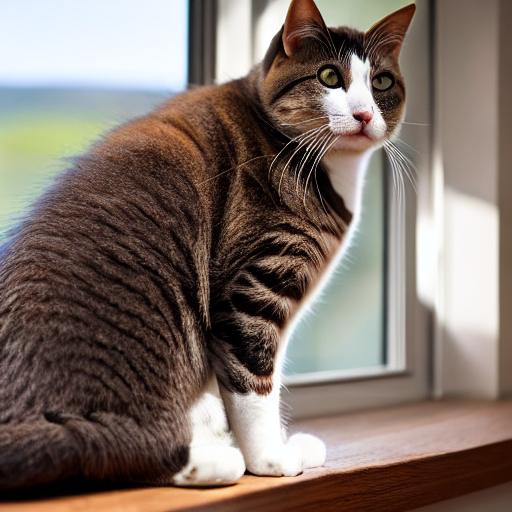


📝 ВАШ ЗАПРОС: кот сидит на подоконнике

✅ Изображение классифицировано как: cat
   Уверенность: 1.00

📋 Сгенерированный промпт: cat, sitting on windowsill, indoor, detailed fur, sunlight, cozy, domestic, realistic,
----------------------------------------

Введите русский запрос для генерации (или 'выход' для завершения):

----------------------------------------
⏳ Генерация изображения...

РЕЗУЛЬТАТ:

🖼️ Сгенерированное изображение:


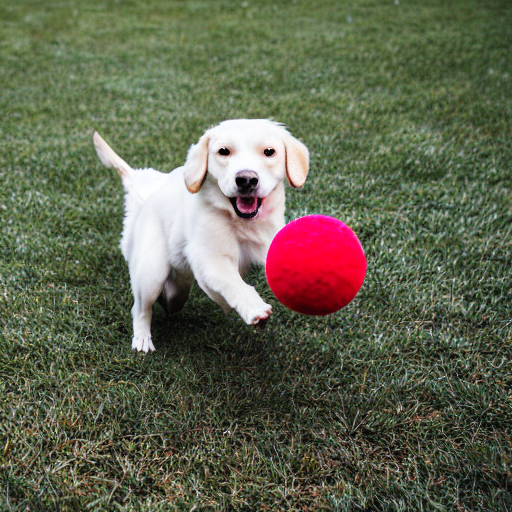


📝 ВАШ ЗАПРОС: собака играет с мячом

✅ Изображение классифицировано как: dog
   Уверенность: 0.95

📋 Сгенерированный промпт: dog, playing with ball, joyful, action shot, detailed fur, realistic, outdoor, playful,
----------------------------------------

Введите русский запрос для генерации (или 'выход' для завершения):

----------------------------------------
⏳ Генерация изображения...

РЕЗУЛЬТАТ:

🖼️ Сгенерированное изображение:


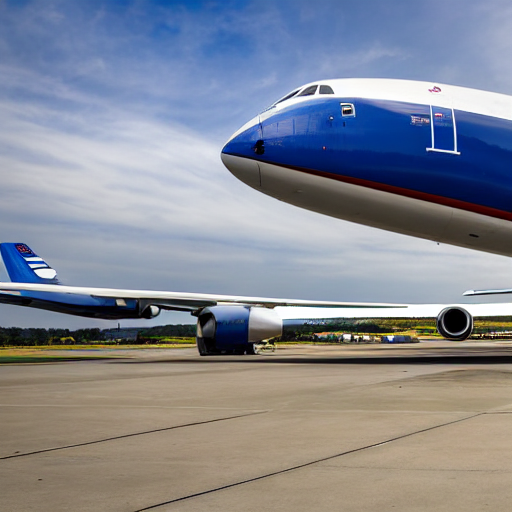


📝 ВАШ ЗАПРОС: самолет крупным планом летит

❌ К сожалению, ваша картинка не относится ни к одному из 8 классов
   (уверенность модели: 0.59)

📋 Сгенерированный промпт: cargo plane, flying with heavy load, detailed, realistic, aviation photography, sky, clouds, airport
----------------------------------------

Введите русский запрос для генерации (или 'выход' для завершения):

----------------------------------------
⏳ Генерация изображения...

РЕЗУЛЬТАТ:

🖼️ Сгенерированное изображение:


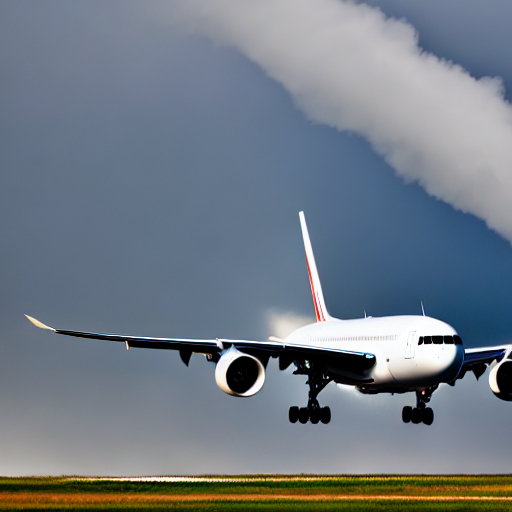


📝 ВАШ ЗАПРОС: самолет летит

✅ Изображение классифицировано как: flower
   Уверенность: 0.83

📋 Сгенерированный промпт: airplane, flying, sky, detailed, realistic, aviation photography, outdoor, clouds, motion blur
----------------------------------------

Введите русский запрос для генерации (или 'выход' для завершения):

----------------------------------------
⏳ Генерация изображения...

РЕЗУЛЬТАТ:

🖼️ Сгенерированное изображение:


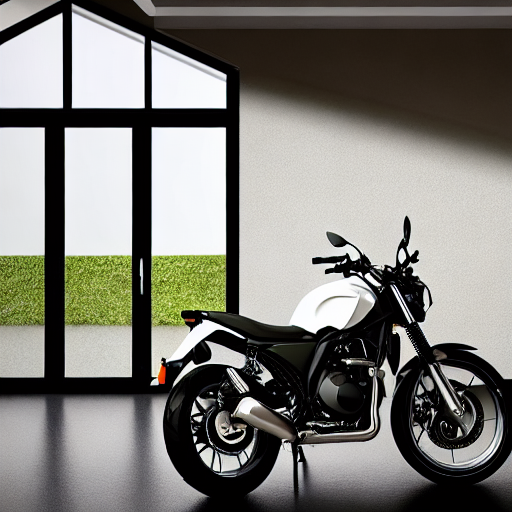


📝 ВАШ ЗАПРОС: мотоцикл стоит в гараже

✅ Изображение классифицировано как: motorbike
   Уверенность: 1.00

📋 Сгенерированный промпт: motorcycle, parked in garage, indoor, detailed, realistic, cozy, domestic, soft lighting,
----------------------------------------

Введите русский запрос для генерации (или 'выход' для завершения):

----------------------------------------
⏳ Генерация изображения...

РЕЗУЛЬТАТ:

🖼️ Сгенерированное изображение:


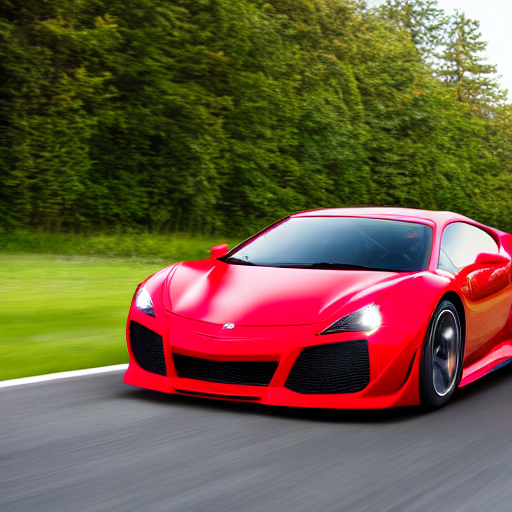


📝 ВАШ ЗАПРОС: красная спортивная машина

✅ Изображение классифицировано как: flower
   Уверенность: 1.00

📋 Сгенерированный промпт: red sports car, shiny, fast, detailed, outdoor, realistic, speed, motion blur, action
----------------------------------------

Введите русский запрос для генерации (или 'выход' для завершения):
Завершение работы...


In [24]:
def user_service(pipeline):
    """Интерактивный сервис для пользователя"""
    print("="*60)
    print("СЕРВИС ГЕНЕРАЦИИ И ВАЛИДАЦИИ ИЗОБРАЖЕНИЙ")
    print("="*60)
    
    while True:
        print("\nВведите русский запрос для генерации (или 'выход' для завершения):")
        user_input = input("> ").strip()
        
        if user_input.lower() in ['выход', 'exit', 'quit']:
            print("Завершение работы...")
            break
        
        if not user_input:
            print("Запрос не может быть пустым!")
            continue
        
        try:
            print("\n" + "-"*40)
            print("⏳ Генерация изображения...")
            
            result = pipeline.process_pipeline(
                russian_prompt=user_input,
                save_image=False  # Не сохраняем в файл, т.к. показываем сразу
            )
            
            # Интерпретация результата
            print("\n" + "="*40)
            print("РЕЗУЛЬТАТ:")
            print("="*40)
            
            # 1. Показываем изображение
            print("\n🖼️ Сгенерированное изображение:")
            display(result['image'])  # Показываем в ноутбуке

            # 2. Выводим исходный запрос пользователя (ДОБАВЬТЕ ЭТОТ БЛОК)
            print("\n" + "="*40)
            print(f"📝 ВАШ ЗАПРОС: {user_input}")
            print("="*40)
            
            # 3. Информация о классификации
            if result['confidence'] < 0.6:
                print("\n❌ К сожалению, ваша картинка не относится ни к одному из 8 классов")
                print(f"   (уверенность модели: {result['confidence']:.2f})")
            else:
                print(f"\n✅ Изображение классифицировано как: {result['predicted_class']}")
                print(f"   Уверенность: {result['confidence']:.2f}")
            
            print(f"\n📋 Сгенерированный промпт: {result['sd_prompt']}")
            print("-"*40)
            
        except Exception as e:
            print(f"❌ Ошибка при обработке: {e}")

# Запускаем сервис
user_service(pipeline)